Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



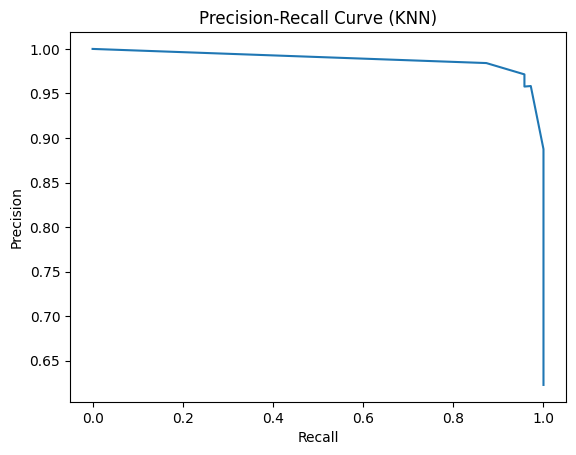

In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 6: Predictions
y_pred_knn = knn.predict(X_test)

# Step 7: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# Step 8: Precision-Recall Curve
y_scores_knn = knn.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores_knn)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (KNN)")
plt.show()

SVM Accuracy: 0.9824561403508771

Confusion Matrix:
 [[41  2]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



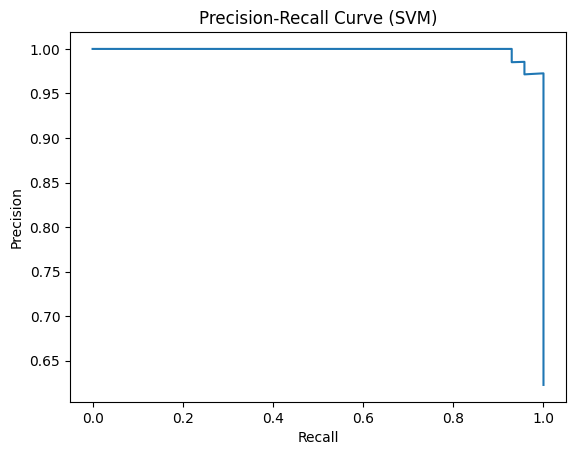

In [ ]:
from sklearn.svm import SVC

# Train SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)

# Prediction
y_pred_svm = svm.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Precision-Recall Curve
y_scores_svm = svm.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores_svm)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve (SVM)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Decision Tree Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



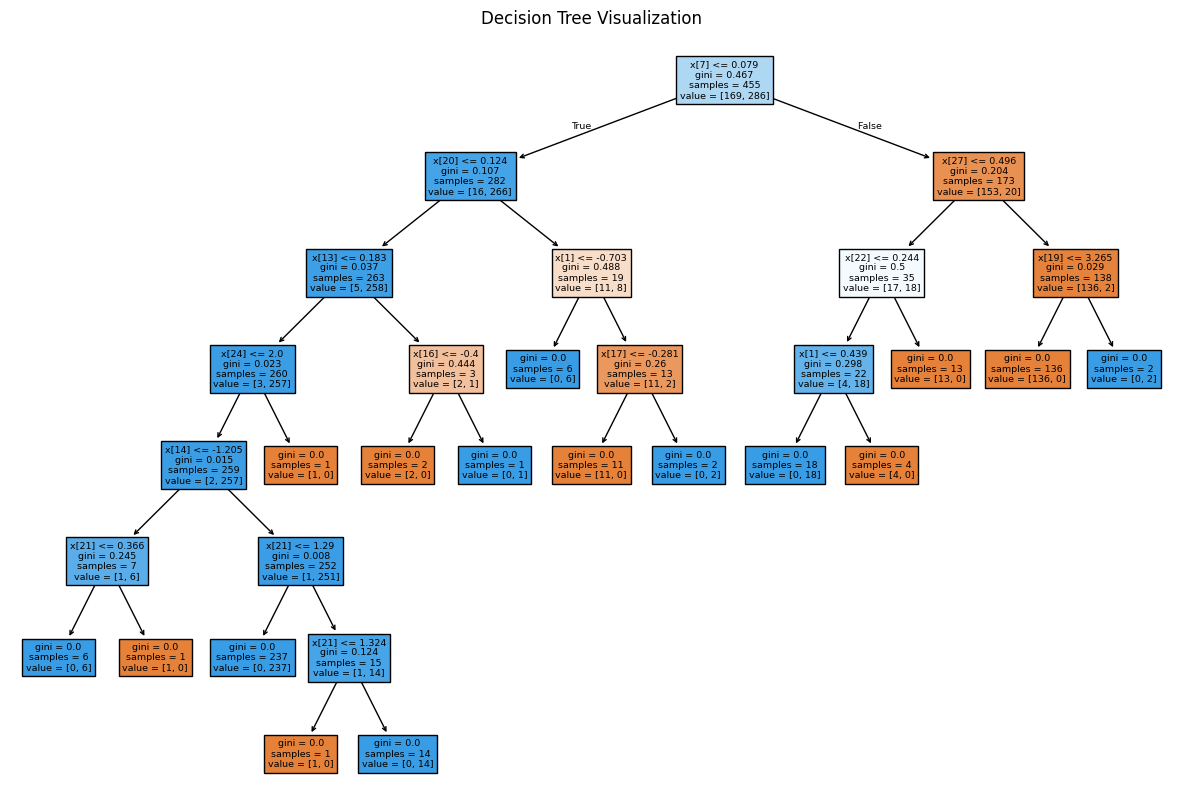

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Visualize Tree
plt.figure(figsize=(15,10))
plot_tree(dt, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

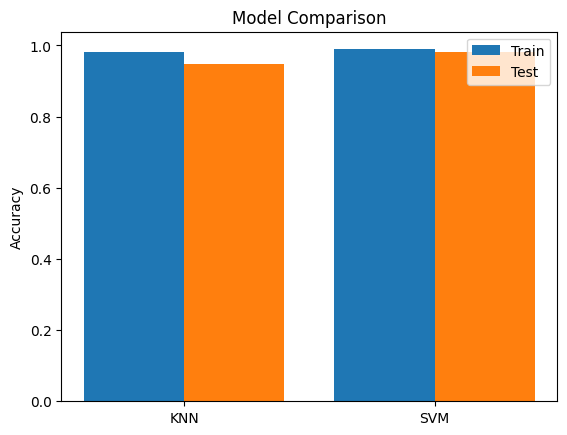

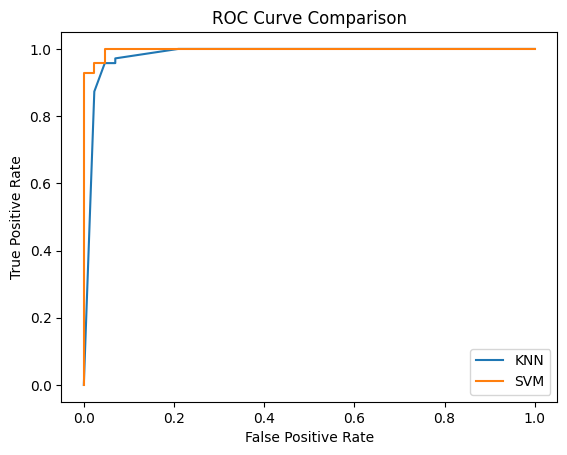

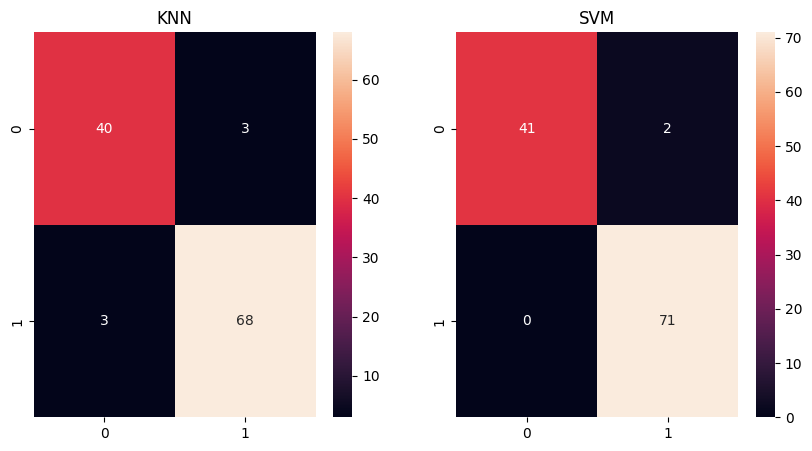

In [ ]:
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# Accuracy comparison
models = ['KNN', 'SVM']
train_acc = [
    knn.score(X_train, y_train),
    svm.score(X_train, y_train)
]

test_acc = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm)
]

# Bar Chart
x = np.arange(len(models))

plt.bar(x - 0.2, train_acc, width=0.4, label='Train')
plt.bar(x + 0.2, test_acc, width=0.4, label='Test')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.show()

# ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_scores_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores_svm)

plt.plot(fpr_knn, tpr_knn, label='KNN')
plt.plot(fpr_svm, tpr_svm, label='SVM')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion Matrix Heatmap
fig, ax = plt.subplots(1, 2, figsize=(10,5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, ax=ax[0])
ax[0].set_title("KNN")

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, ax=ax[1])
ax[1].set_title("SVM")

plt.show()